# 1. (a) 
Recall:
A _transition Monoid_ is the set $T_\mathcal{A}$ of all products of elements from $X = \{ t_a : a \in \Sigma \} $. We are provided with the fact that a DFA $\mathcal{A}$ is synchronizing if and only if it's transition monoid $T_\mathcal{A}$ contains some constant transformation $t$.

## Algorithm:
We wish to test if a given DFA $\mathcal{A}$ is synchronizing by using a breadth-first search to find a constant transformation in the transition monoid $T_\mathcal{A}$, if it exists.

For each symbol $a \in \Sigma$ we have that $a$ induces some transformation $t_a : Q \to Q$. We search the space of transformations breadth first (BFS) in order to find a constant transformation. If the search exhausts then we conclude no such transform exists. The Cerny conjecture bounds the length of a reset word thus it also bounds our BFS.

1. For each $a \in \Sigma$, we compute the transformation induced by $a$. This set forms the "generators" of our transition monoid. Naturally, our BFS starts by searching the generators. 

2. We can continue searching the monoid by constructing products of generators (increasing depth) and repeating the process we return `True` when the constant criteria has been met, and otherwise return `False`


We can optimise this by checking if a single letter transformation induces a permutation on the set of states, if that is the case then the monoid is generated by permutations and cannot contain a reset word. This is significantly faster than exhausting the monoid, only requiring $O(n|\Sigma|)$ saving time.



In [3]:
def all_generators_permutations(A):
    
    Q, S, t, q_s, F = A
    states = sorted(Q)
    n = len(states)

    for a in S:
        images = {t[(q, a)] for q in states}
        if len(images) < n:       # some pair of states collapses, so a is not a bijection
            return False

    return True

In [8]:
from collections import deque

def is_synchronizing(A):
    
    """
    Our function takes as input a DFA A = (Q, S, t, q_s, F)
    Where each variable carries it's usual meaning from the question.
    i.e. 
    
    Q           : States
    S = Sigma   : Alphabet 
    t = tau     : transition function 
    q_s         : start state
    F           : Accept states
    
    Returns True, False
    """
    Q, S, t, q_s, F = A
    states = sorted(Q)                                   # sort for consistency
    n = len(states)
    
    if all_generators_permutations(A):
        return False

    generators = {}
    for a in S:
        generators[a] = tuple(t[(q, a)] for q in states)  # as given in the question

    def is_constant(trans):                               # check if a transformation is constant
        return len(set(trans)) == 1                       # Returns True if we have met our criteria

    visited = set()
    queue = deque()                                       # use deque() as a faster way of enforcing BFS

    for a in S:                                           # "seed the queue" with generators of T_A
        transform = generators[a]
        if transform not in visited:                      # Check if we have visited yet 
            if is_constant(transform):                    # Check if constant 
                return True
            visited.add(transform)
            queue.append(transform)

    while queue:                                           
        current = queue.popleft()                                        # "shortest" transforms (breadth first) sit at the left
        for a in S:
            gen = generators[a]
            product_transform = tuple(gen[current[i]] for i in range(n)) # increase depth, this computes e.g. t_1 * t_0 or "two letter transforms"
            if product_transform not in visited:
                if is_constant(product_transform):                       # check again for constant and repeat
                    return True
                visited.add(product_transform)
                queue.append(product_transform)

    return False

In [5]:
# Test cell

Q = {0, 1, 2, 3}
S = {'0', '1'}
t = {
    (0, '0'): 1, (1, '0'): 0, (2, '0'): 1, (3, '0'):2,
    (0, '1'): 0, (1, '1'): 2, (2, '1'): 0, (3, '1'):0
}

q_s = 3
F = {1, 2}

A = (Q, S, t, q_s, F)

sync = is_synchronizing(A)
if sync:
    print(f"Synchronizing!")
else:
    print("Not synchronizing")

Synchronizing!


In [9]:
def is_synchronizing2(A):                              # without perm check
    
    
    Q, S, t, q_s, F = A
    states = sorted(Q)                                   # sort for consistency
    n = len(states)

    generators = {}
    for a in S:
        generators[a] = tuple(t[(q, a)] for q in states)  # as given in the question

    def is_constant(trans):                               # check if a transformation is constant
        return len(set(trans)) == 1                       # Returns True if we have met our criteria

    visited = set()
    queue = deque()                                       # use deque() as a faster way of enforcing BFS

    for a in S:                                           # "seed the queue" with generators of T_A
        transform = generators[a]
        if transform not in visited:                      # Check if we have visited yet 
            if is_constant(transform):                    # Check if constant 
                return True
            visited.add(transform)
            queue.append(transform)

    while queue:                                           
        current = queue.popleft()                                        # "shortest" transforms (breadth first) sit at the left
        for a in S:
            gen = generators[a]
            product_transform = tuple(gen[current[i]] for i in range(n)) # increase depth, this computes e.g. t_1 * t_0 or "two letter transforms"
            if product_transform not in visited:
                if is_constant(product_transform):                       # check again for constant and repeat
                    return True
                visited.add(product_transform)
                queue.append(product_transform)

    return False

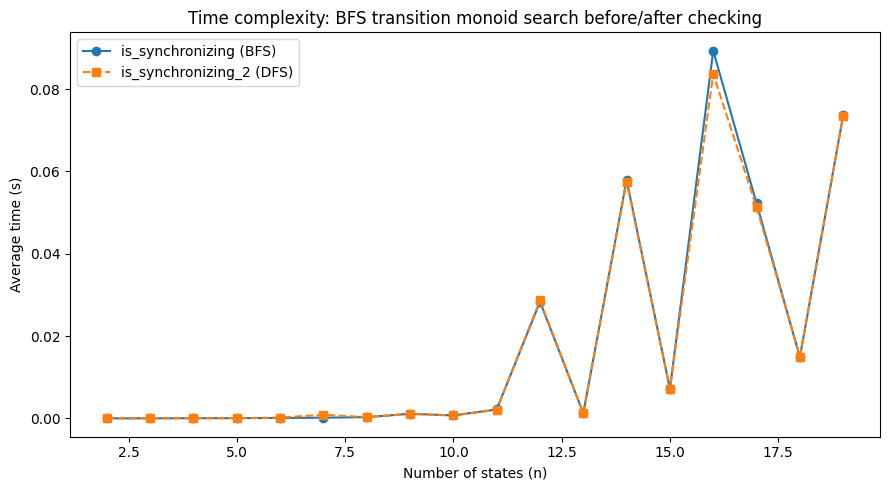

In [ ]:
import time
import random
import matplotlib.pyplot as plt

def random_dfa(n, sigma=('0', '1')):
    # Generate a random DFA with n states over the given alphabet.
    Q = set(range(n))
    S = set(sigma)
    t = {(q, a): random.randint(0, n - 1) for q in Q for a in S}
    return (Q, S, t, 0, set())

def benchmark(func, dfa, repeats=5):
    # Return average wall-clock time for func(dfa) over several runs.
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        func(dfa)
        times.append(time.perf_counter() - start)
    return sum(times) / len(times)

# time functions
sizes = list(range(2, 20))
repeats_per_size = 20          # average over this many random DFAs per size

times_bfs = []
times_dfs = []

for n in sizes:
    t_bfs, t_dfs = [], []
    for _ in range(repeats_per_size):
        dfa = random_dfa(n)
        t_bfs.append(benchmark(is_synchronizing,   dfa))
        t_dfs.append(benchmark(is_synchronizing2, dfa))
    times_bfs.append(sum(t_bfs) / len(t_bfs))
    times_dfs.append(sum(t_dfs) / len(t_dfs))

# plot
plt.figure(figsize=(9, 5))
plt.plot(sizes, times_bfs, marker='o', label='is_synchronizing (Check)')
plt.plot(sizes, times_dfs, marker='s', label='is_synchronizing_2 (No Check)', linestyle='--')
plt.xlabel('Number of states (n)')
plt.ylabel('Average time (s)')
plt.title('Time complexity: BFS transition monoid search before/after checking')
plt.legend()
plt.tight_layout()
plt.show()